<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Data Science and Business Analytics</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>
<center><font size=6>By</font></center>
<center><font size=7>Joseph Anyanwu</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [1]:
import warnings

warnings.filterwarnings("ignore")

# This will help in making the Python code more structured automatically (good coding practice)
%load_ext jupyter_black

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)
# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# **Loading the dataset**

In [3]:
ezyv = pd.read_csv("Downloads/EasyVisa.csv")

# **Overview of the Dataset**

In [5]:
# number of rows and columns in the data
ezyv.shape

(25480, 12)

There 25,480 rows and 12 columns in the data

In [7]:
# let's create a copy of the data
df = ezyv.copy()

In [9]:
# let's view the first 5 rows of the data
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [11]:
# let's view the last 5 rows of the data
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [13]:
# let's Check the data types of the columns for the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [15]:
# let's check for duplicate values in the data
df.duplicated().sum()

0

There are no duplicates in the data set

In [17]:
# let's check for missing values in the data
round(df.isnull().sum() / df.isnull().count() * 100, 2)

case_id                 0.000
continent               0.000
education_of_employee   0.000
has_job_experience      0.000
requires_job_training   0.000
no_of_employees         0.000
yr_of_estab             0.000
region_of_employment    0.000
prevailing_wage         0.000
unit_of_wage            0.000
full_time_position      0.000
case_status             0.000
dtype: float64

There are no missing values in the data set

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

**Let's check the statistical summary of the data**

In [19]:
# let's view the statistical summary of the numerical columns in the data
df.describe().T
# to include all columns
# df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


**Observations**
* `no_of_employees:` the average no_of_employees is 5667. The lowest count  is showing as negative (-26), which could be an error while the max is 602069
* `yr_of_estab:` The range of the year of establishment is large and starts from 1800 to 2016.
* `prevailing_wage:` The wages paid have a wide range from 2.137 to 319210. The average wages paid is 74455, while 75% of the wages paid is over 107000.

**Let's check the percentage distribution of each unique category in each of the variables**

In [21]:
# listing of all the variables' values
t_col = df.columns

# printing the number of occurrences of each unique value in each categorical column
for column in t_col:
    print(df[column].value_counts(normalize=True))
    print("-" * 50)

case_id
EZYV01      0.000
EZYV16995   0.000
EZYV16993   0.000
EZYV16992   0.000
EZYV16991   0.000
             ... 
EZYV8492    0.000
EZYV8491    0.000
EZYV8490    0.000
EZYV8489    0.000
EZYV25480   0.000
Name: proportion, Length: 25480, dtype: float64
--------------------------------------------------
continent
Asia            0.662
Europe          0.146
North America   0.129
South America   0.033
Africa          0.022
Oceania         0.008
Name: proportion, dtype: float64
--------------------------------------------------
education_of_employee
Bachelor's    0.402
Master's      0.378
High School   0.134
Doctorate     0.086
Name: proportion, dtype: float64
--------------------------------------------------
has_job_experience
Y   0.581
N   0.419
Name: proportion, dtype: float64
--------------------------------------------------
requires_job_training
N   0.884
Y   0.116
Name: proportion, dtype: float64
--------------------------------------------------
no_of_employees
183     0.001
854 

In [23]:
# checking the number of unique values
df["case_id"].nunique()

25480

`case_id` is a variable with unique values, so will need to be dropped.

In [25]:
# enrollee_id is unique for each candidate and might not add value to modeling
df.drop(["case_id"], axis=1, inplace=True)

**Fixing the negative values in number of employees columns**

In [27]:
df.loc[df["no_of_employees"] < 0].shape

(33, 11)

There are 33 rows with negative values.
  - We will consider the 33 observations as data entry errors and take the absolute values for this column.

In [29]:
#  taking the absolute values for number of employees
df["no_of_employees"] = abs(df["no_of_employees"])

In [31]:
# let's view the statistical summary of the no_of_employees in the data
df["no_of_employees"].describe().T

count    25480.000
mean      5667.089
std      22877.917
min         11.000
25%       1022.000
50%       2109.000
75%       3504.000
max     602069.000
Name: no_of_employees, dtype: float64

We fixed the negative values in the dataset

In [33]:
# create another copy of the data
data = df.copy()

The negative values have been removed from `no_of_employees` variable

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

In [35]:
# function to create labeled barplots


def labeled_barplot(
    data, feature, perc=False, n=None, title=None, xlabel=None, ylabel=None
):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if p.get_height() > 0:  # Exclude zero-height bars
            if perc:
                label = "{:.1f}%".format(100 * p.get_height() / total)
            else:
                label = p.get_height()

            x = p.get_x() + p.get_width() / 2
            y = p.get_height()

            ax.annotate(
                label,
                (x, y),
                ha="center",
                va="bottom",  # Ensures label is placed above the bar
                size=10,
                xytext=(0, 5),
                textcoords="offset points",
            )

    if title:  # Add title if provided
        plt.title(title, fontsize=14)
    if xlabel:  # Add xlabel if provided
        plt.xlabel(xlabel, fontsize=12)
    if ylabel:  # Add ylabel if provided
        plt.ylabel(ylabel, fontsize=12)

    plt.show()  # show the plot

In [37]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target, title=None, xlabel=None, ylabel=None):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    title: title of the plot (default is None)
    xlabel: label for the x-axis (default is None)
    ylabel: label for the y-axis (default is None)
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

    if xlabel:  # Add xlabel if provided
        plt.xlabel(xlabel, fontsize=12)
    if ylabel:  # Add ylabel if provided
        plt.ylabel(ylabel, fontsize=12)
    if title:  # Add title if provided
        plt.title(title, fontsize=14)

    plt.show()

In [39]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(10, 5), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (10,5))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    mean_val = data[feature].mean()
    median_val = data[feature].median()

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    (
        sns.histplot(
            data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, stat="density"
        )
        if bins
        else sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, stat="density")
    )  # For histogram, changed stat to 'density'

    # Add vertical lines for mean and median with labels inside the plot
    ax_hist2.axvline(
        data[feature].mean(),
        color="green",
        linestyle="--",
        label=f'Mean: {data["no_of_employees"].mean():.0f}',
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(),
        color="black",
        linestyle="-",
        label=f'Median: {data["no_of_employees"].median():.0f}',
    )  # Add median to the histogram

    plt.tight_layout()
    plt.legend()
    plt.show()

In [41]:
### function to see distribution on histogram and boxplot


def histogram_boxplot2(
    data, feature, figsize=(10, 5), kde=False, bins=None, focus_percentile=None
):
    """
    Boxplot and histogram combined, with optional x-axis focusing.

    Parameters:
    - data: DataFrame
    - feature: column name (str)
    - figsize: size of figure (default (10,5))
    - kde: whether to show the density curve (default False)
    - bins: number of bins for histogram (default None)
    - focus_percentile: if provided, limits x-axis up to this percentile for better visualization (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    # creating the 2 subplots
    # 1 Boxplot
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="violet")

    # 2 Histogram
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins)
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)

    # Plot mean and median lines
    mean_val = data[feature].mean()
    median_val = data[feature].median()

    ax_hist2.axvline(
        mean_val, color="green", linestyle="--", label=f"Mean: {mean_val:.0f}"
    )
    ax_hist2.axvline(
        median_val, color="black", linestyle="-", label=f"Median: {median_val:.0f}"
    )

    # Optionally adjust x-axis to focus on specific percentile
    if focus_percentile is not None:
        x_limit = np.percentile(data[feature].dropna(), focus_percentile)
        ax_hist2.set_xlim(0, x_limit)

    # Add legend
    ax_hist2.legend()

    plt.tight_layout()
    plt.show()

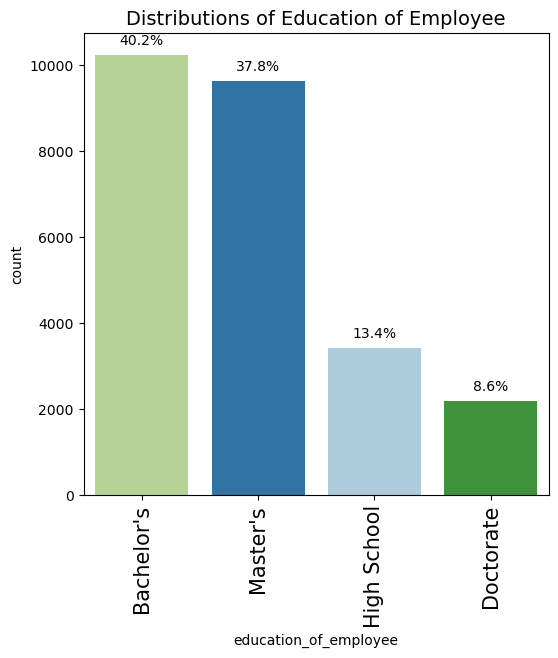

In [43]:
# Observations on education of employee
labeled_barplot(
    data,
    "education_of_employee",
    perc=True,
    title="Distributions of Education of Employee",
)

Majority of the workers at least, have a Bachelor's degrees, with 13.4% having only High School diploma as the highest level of education.

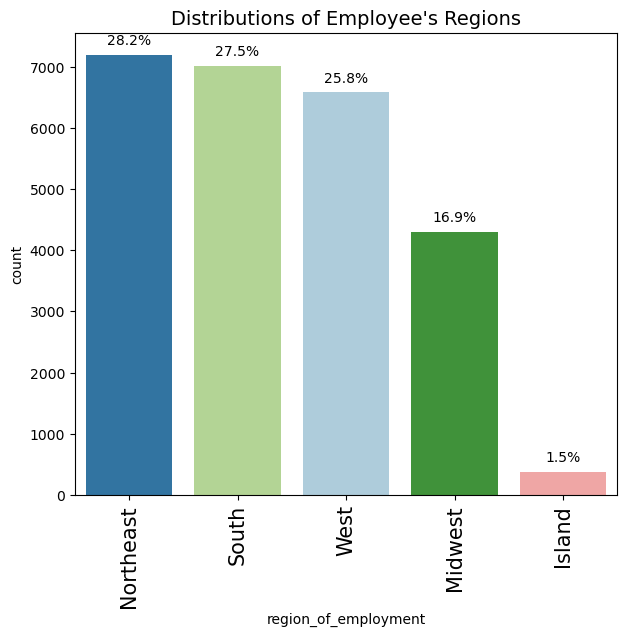

In [47]:
# Observations on region_of_employment
labeled_barplot(
    data, "region_of_employment", perc=True, title="Distributions of Employee's Regions"
)

Island region has the lowest representation for the workers while Northeast is the highest

Observations on no_of_employees
----------------------------------------------------------------------------------------------------


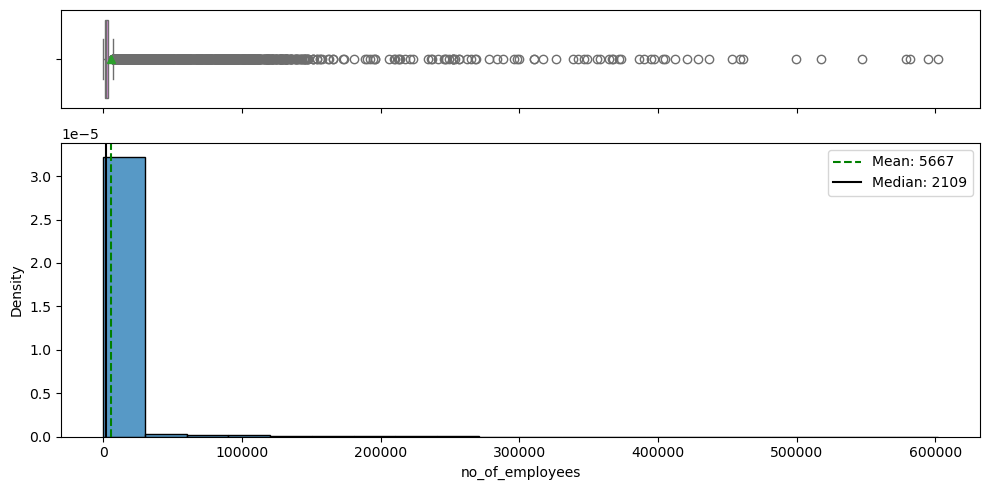

In [53]:
# Observations on no_of_employees
print("Observations on no_of_employees")
print("--" * 50)

histogram_boxplot(data, "no_of_employees", bins=20)
# histogram_boxplot2(data, "no_of_employees", bins=20, focus_percentile=95)

The average number of employees which depicts the company size is 5667 with a median of 2109. There are companies with significanly higher size as shown in the outliers on the boxplot.

***Question 1. What is the distribution of visa case statuses (certified vs. denied)?***




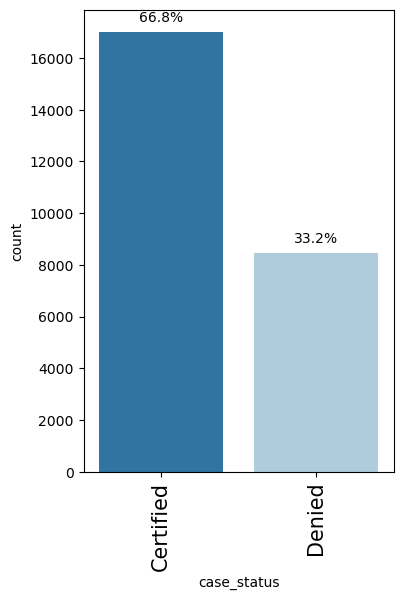

In [55]:
# Observations on case status
labeled_barplot(data, "case_status", perc=True)

The distribution of visa case statuses (certified vs. denied) is ~67% for certified and ~33% for Denied, making it imbalanced

##**Bivariate Analysis**

In [58]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

***Question 2. How does the education level of employees impact visa approval rates?***

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


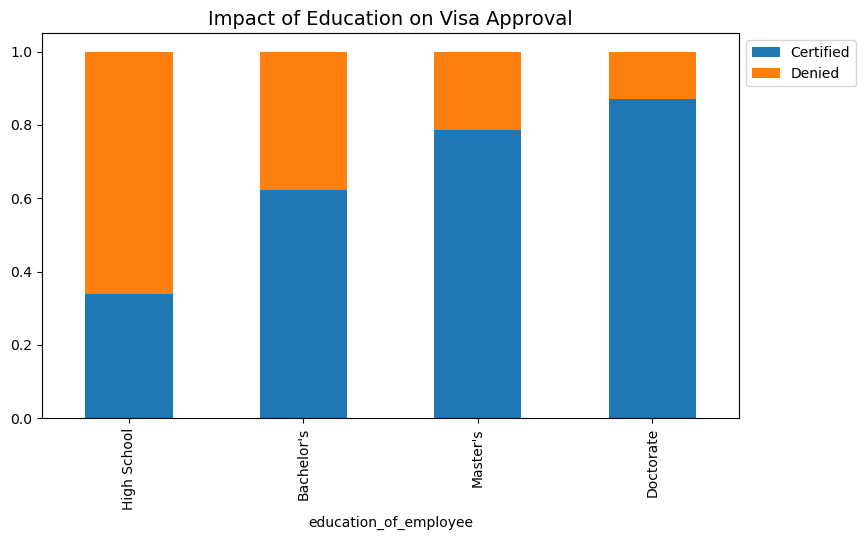

In [60]:
stacked_barplot(
    data,
    "education_of_employee",
    "case_status",
    title="Impact of Education on Visa Approval",
)

With 87% certified approval rates, Workers with Doctorate degree have the highest chances of being certified followed by those with Masters at 79%. High School workers are the least certified for a visa with just 34% approval rates.

***Question 3. Is there a significant difference in visa approval rates between employees with and without prior job experience?***

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


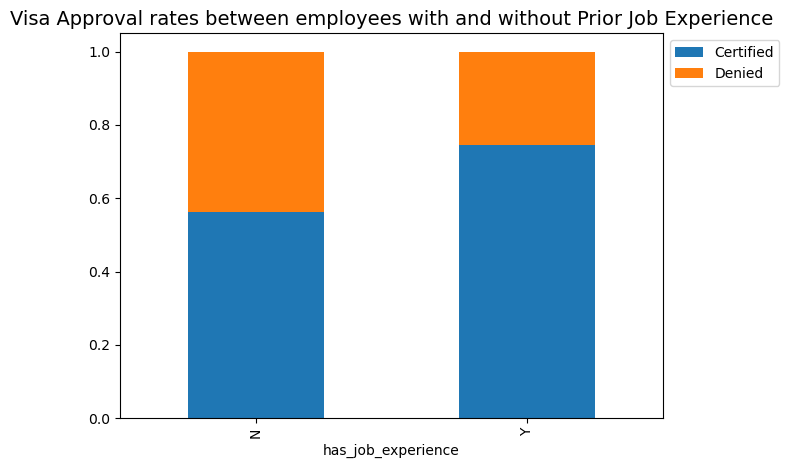

In [62]:
stacked_barplot(
    data,
    "has_job_experience",
    "case_status",
    title="Visa Approval rates between employees with and without Prior Job Experience",
)

There is a significant difference in visa approval rates between employees with and without prior job experience. Employees with job experience have more certified visa approval (65%) than employees without experience (35%).

***Question 4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?***

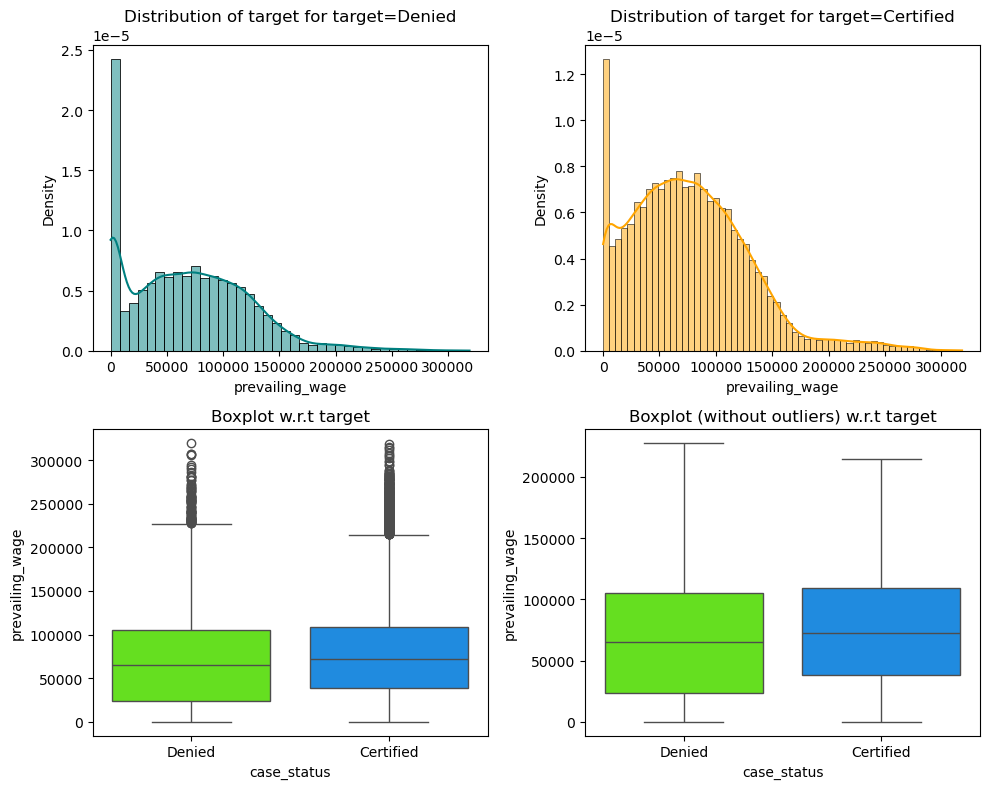

In [64]:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

Prevailing wage affects the visa approval status.
- While both Denied and Certified cases show a right-skewed distribution of prevailing wages, Certified applications seem to be denser a little more around higher wage values (around ~70,000–$100,000) compared to Denied cases.
- The higher the wage, the higher the chances of certified approval as shown the plot where the median wage of the certified workers is higher than denied workers.

***Question 5. Do certain regions in the US have higher visa approval rates compared to others?***

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


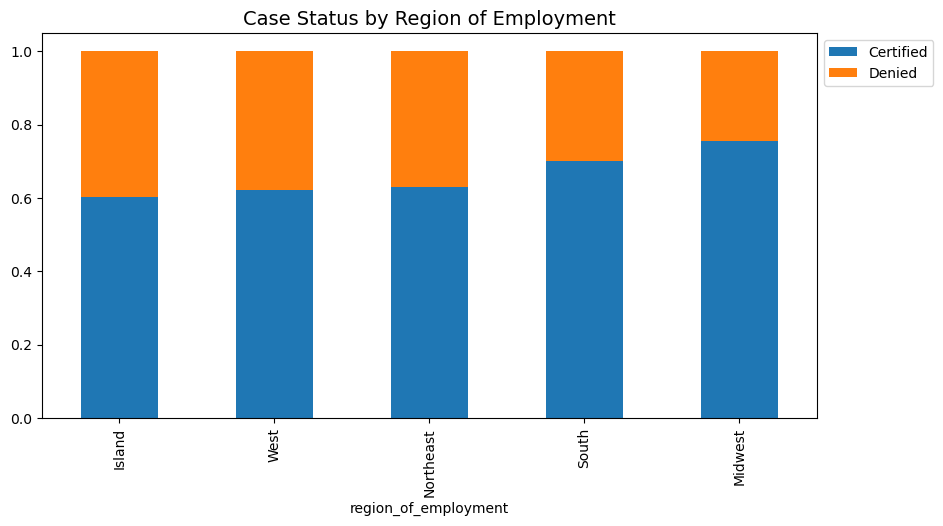

In [66]:
stacked_barplot(
    data,
    "region_of_employment",
    "case_status",
    title="Case Status by Region of Employment",
)

- The Midwest region has the highest approval rate with 76%, followed by the South region (70%).
- Northeast, West, and Island regions have lower certification rates and higher denial rates
- The Island region has the lowest rate at 60%.

***Question 6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate (certified or denied)?***

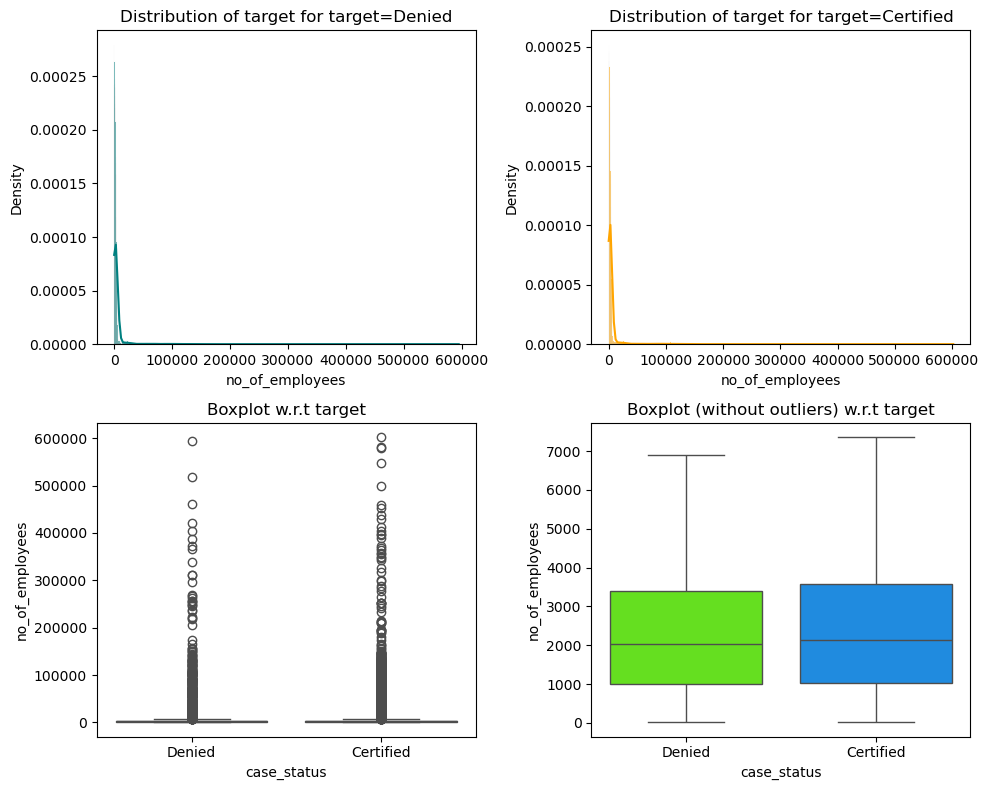

In [68]:
distribution_plot_wrt_target(data, "no_of_employees", "case_status")

The charts don't definitively prove that larger companies (higher no. of employees) have a significantly higher approval rate, but they do indicate a tendency for certified cases to be associated with slightly larger companies compared to denied cases, looking at the median.

* While both denials and certifications happen across companies of all sizes, the median company size(number of employees) for certified visas is **slightly higher** than the median company size(number of employees) for denied visas when outliers (very large companies) are excluded from the central comparison.

* However, it's important to note the significant overlap in the distributions shown in the boxplots. Many smaller companies receive certifications, and many larger companies receive denials.

***Question 7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?***

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


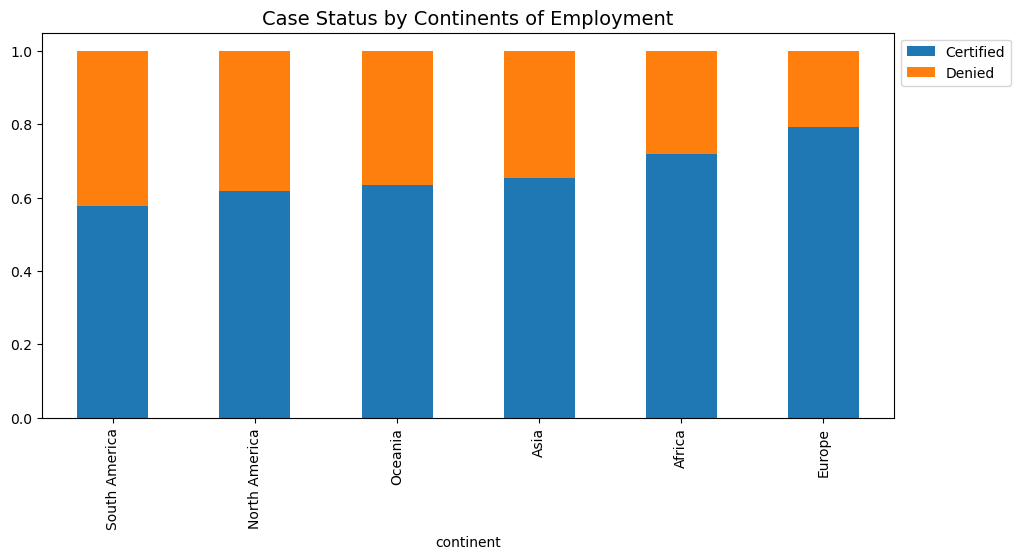

In [70]:
# check for visa status vary across different continents.
stacked_barplot(
    data, "continent", "case_status", title="Case Status by Continents of Employment"
)

- The continent of Europe has the highest approval rate with 79%, followed by the continents of Africa (72%) and Asia (65%).

- The continent of South America has the lowest rate at 58%.

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [72]:
# check the number of ubique values in the column
data["yr_of_estab"].nunique()

199

* There are 199 values for the year of establishment which though numerical datatype, is categorical.

We will do a featured engineering on the `yr_of_estab` so that we can categorize it into 3 for analysis.

* First we create a company age variable based on the year of establishment.

* We then write a code to categorize cities based on their development index using a technique called **quantile-based discretization** and then assign them a label as "**Young**", "**Mature**", "**Legacy**" respectively.

**pd.qcut(...)**: This is the core function doing the work. `pd.qcut` is a function from the Pandas library (pd) that divides the data into quantiles. This ensures that each category or 'bin' contains roughly the same number of cities.

In [74]:
from datetime import datetime

# Calculate company age
current_year = datetime.now().year
data["company_age"] = current_year - data["yr_of_estab"]

In [76]:
# perform the quantile cut

data["company_group"] = pd.qcut(
    data["company_age"],
    q=[0, 0.25, 0.5, 1],
    labels=["Young", "Mature", "Legacy"],
)

In [78]:
data["company_group"].value_counts()

company_group
Legacy    12246
Young      6751
Mature     6483
Name: count, dtype: int64

Now we drop 'yr_of_estab` and `company_age` from the data

In [80]:
# drop 'yr_of_estab' from the data to avoid multicolinearity
data.drop(["yr_of_estab"], axis=1, inplace=True)

In [84]:
# save a copy of the data
data1 = data.copy()

#### We need to pass numerical values for each categorical column for imputation so we will label encode them using `.map()` function.

In [87]:
# we need to pass numerical values for each categorical column for imputation so we will label encode them
continent = {
    "Asia": 0,
    "Africa": 1,
    "Europe": 3,
    "North America": 4,
    "South America": 5,
    "Oceania": 6,
}
data["continent"] = data["continent"].map(continent)

has_job_experience = {"Y": 1, "N": 0}
data["has_job_experience"] = data["has_job_experience"].map(has_job_experience)

education_of_employee = {
    "High School": 0,
    "Bachelor's": 1,
    "Master's": 2,
    "Doctorate": 3,
}
data["education_of_employee"] = data["education_of_employee"].map(education_of_employee)

region_of_employment = {
    "Northeast": 0,
    "Midwest": 1,
    "South": 2,
    "West": 3,
    "Island": 4,
}
data["region_of_employment"] = data["region_of_employment"].map(region_of_employment)

company_group = {"Young": 0, "Mature": 1, "Legacy": 2}
data["company_group"] = data["company_group"].map(company_group)

unit_of_wage = {"Hour": 0, "Week": 1, "Month": 2, "Year": 3}
data["unit_of_wage"] = data["unit_of_wage"].map(unit_of_wage)

requires_job_training = {"Y": 1, "N": 0}
data["requires_job_training"] = data["requires_job_training"].map(requires_job_training)

full_time_position = {"Y": 1, "N": 0}
data["full_time_position"] = data["full_time_position"].map(full_time_position)

In [89]:
# check to confirm successful label encoding.
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age,company_group
0,0,0,0,0,14513,3,592.203,0,1,Denied,18,0
1,0,2,1,0,2412,0,83425.650,3,1,Certified,23,1
2,0,1,0,1,44444,3,122996.860,3,1,Denied,17,0
3,0,1,0,0,98,3,83434.030,3,1,Denied,128,2
4,1,2,1,0,1082,2,149907.390,3,1,Certified,20,0


In [91]:
# check data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  int64   
 1   education_of_employee  25480 non-null  int64   
 2   has_job_experience     25480 non-null  int64   
 3   requires_job_training  25480 non-null  int64   
 4   no_of_employees        25480 non-null  int64   
 5   region_of_employment   25480 non-null  int64   
 6   prevailing_wage        25480 non-null  float64 
 7   unit_of_wage           25480 non-null  int64   
 8   full_time_position     25480 non-null  int64   
 9   case_status            25480 non-null  object  
 10  company_age            25480 non-null  int64   
 11  company_group          25480 non-null  category
dtypes: category(1), float64(1), int64(9), object(1)
memory usage: 2.2+ MB


## Split Data into X and y

In [93]:
# separating the independent and dependent variables
X = data.drop(["case_status"], axis=1)
y = data["case_status"].apply(
    lambda x: 1 if x == "Certified" else 0
)  # replace Certified and Denied with 1 and 0 respectively

# creating dummy variables
# X = pd.get_dummies(X, drop_first=True)

Split into Train, Validation and Test Set

In [95]:
# Splitting data into training, validation and test set:

# first we split data into 2 parts, say temporary and test. We allocate 20% of the data to the test set and 80% to temporary set.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set ( the remaining 80% of the data after the initial split for testing.) into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
# This means that we allocate 25% of X_temp and y_temp to the validation set (X_val, y_val). The remaining 75% (originally 60% of data) forms the training data (X_train, y_train)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 11) (5096, 11) (5096, 11)


In summary, the above code takes the original dataset and splits it into three parts: training (60%), validation (20%), and testing (20%). These splits are essential for training, evaluating, and testing the machine learning model.

In [97]:
# Checking class balance for whole data, train set, validation set, and test set

print("Target value ratio in y")
print(y.value_counts(1))
print("*" * 80)
print("Target value ratio in y_train")
print(y_train.value_counts(1))
print("*" * 80)
print("Target value ratio in y_val")
print(y_val.value_counts(1))
print("*" * 80)
print("Target value ratio in y_test")
print(y_test.value_counts(1))
print("*" * 80)

Target value ratio in y
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64
********************************************************************************
Target value ratio in y_train
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64
********************************************************************************
Target value ratio in y_val
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64
********************************************************************************
Target value ratio in y_test
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64
********************************************************************************


The train-test-split command has retained the original ratio (~67:33) of the target distribution

In [99]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 15288
Number of rows in validation data = 5096
Number of rows in test data = 5096


In [101]:
# Checking that no column has missing values in train, validation or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
company_age              0
company_group            0
dtype: int64
------------------------------
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
company_age              0
company_group            0
dtype: int64
------------------------------
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
company_age              0
company_group            0
dtype: int64


### Reverse Mapping for the label encoded Variables
  - Bring the variables back to original values before label encoding and mapping and convert them to category data types

In [103]:
## Function to inverse the encoding
def inverse_mapping(x, y):
    inv_dict = {v: k for k, v in x.items()}
    X_train[y] = np.round(X_train[y]).map(inv_dict).astype("category")
    X_val[y] = np.round(X_val[y]).map(inv_dict).astype("category")
    X_test[y] = np.round(X_test[y]).map(inv_dict).astype("category")

In [105]:
inverse_mapping(continent, "continent")
inverse_mapping(education_of_employee, "education_of_employee")
inverse_mapping(has_job_experience, "has_job_experience")
inverse_mapping(requires_job_training, "requires_job_training")
inverse_mapping(region_of_employment, "region_of_employment")
inverse_mapping(unit_of_wage, "unit_of_wage")
inverse_mapping(full_time_position, "full_time_position")
inverse_mapping(company_group, "company_group")

### Checking inverse mapped values/categories.

* `Train Set`

In [107]:
cols = X_train.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_train[i].value_counts())
    print("*" * 30)

continent
Asia             10085
Europe            2285
North America     1944
South America      528
Africa             333
Oceania            113
Name: count, dtype: int64
******************************
education_of_employee
Bachelor's     6141
Master's       5792
High School    2045
Doctorate      1310
Name: count, dtype: int64
******************************
has_job_experience
Y    8845
N    6443
Name: count, dtype: int64
******************************
requires_job_training
N    13477
Y     1811
Name: count, dtype: int64
******************************
region_of_employment
Northeast    4312
South        4248
West         3920
Midwest      2576
Island        232
Name: count, dtype: int64
******************************
unit_of_wage
Year     13786
Hour      1286
Week       156
Month       60
Name: count, dtype: int64
******************************
full_time_position
Y    13678
N     1610
Name: count, dtype: int64
******************************
company_group
Legacy    7303
Young     4095

* `Validation Set`

In [109]:
cols = X_val.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_val[i].value_counts())
    print("*" * 30)

continent
Asia             3395
Europe            713
North America     655
South America     173
Africa            121
Oceania            39
Name: count, dtype: int64
******************************
education_of_employee
Bachelor's     2033
Master's       1886
High School     694
Doctorate       483
Name: count, dtype: int64
******************************
has_job_experience
Y    2963
N    2133
Name: count, dtype: int64
******************************
requires_job_training
N    4501
Y     595
Name: count, dtype: int64
******************************
region_of_employment
Northeast    1430
South        1389
West         1352
Midwest       855
Island         70
Name: count, dtype: int64
******************************
unit_of_wage
Year     4576
Hour      452
Week       57
Month      11
Name: count, dtype: int64
******************************
full_time_position
Y    4552
N     544
Name: count, dtype: int64
******************************
company_group
Legacy    2464
Young     1366
Mature    126

* `Test Set`

In [111]:
cols = X_test.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_test[i].value_counts())
    print("*" * 30)

continent
Asia             3381
Europe            734
North America     693
South America     151
Africa             97
Oceania            40
Name: count, dtype: int64
******************************
education_of_employee
Bachelor's     2060
Master's       1956
High School     681
Doctorate       399
Name: count, dtype: int64
******************************
has_job_experience
Y    2994
N    2102
Name: count, dtype: int64
******************************
requires_job_training
N    4547
Y     549
Name: count, dtype: int64
******************************
region_of_employment
Northeast    1453
South        1380
West         1314
Midwest       876
Island         73
Name: count, dtype: int64
******************************
unit_of_wage
Year     4600
Hour      419
Week       59
Month      18
Name: count, dtype: int64
******************************
full_time_position
Y    4543
N     553
Name: count, dtype: int64
******************************
company_group
Legacy    2479
Mature    1327
Young     129

In [113]:
# create dummy variables to categorize into numerical data

X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 23) (5096, 23) (5096, 23)


# **Model Building**

#Model evaluation criterion
**Model can make wrong predictions as:**

* Model predicts that the visa application will get certified but in reality, the visa application should get denied.
* Model predicts that the visa application will not get certified but in reality, the visa application should get certified.

**Both the cases are important as**:

  - If a visa is certified when it had to be denied a wrong employee will get the job position while US citizens will miss the opportunity to work on that position.

  - If a visa is denied when it had to be certified the U.S. will lose a suitable human resource that can contribute to the economy.

**F1 Score** will be used as the metric for evaluation of the model. The greater the F1 score, the higher are the chances of minimizing False Negatives and False Positives.

We will use balanced class weights so that model focuses equally on both classes.

In [115]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [117]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Initial Model Building

### Model Building - Original Data

In [119]:
# checks for only F1_score

models = []  # Empty list to store all the models

# Appending models into the list
models.append(
    (
        "Bagging",
        BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=1, class_weight="balanced"),
            random_state=1,
        ),
    )
)
models.append(
    ("Random forest", RandomForestClassifier(random_state=1, class_weight="balanced"))
)
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(
    ("dtree", DecisionTreeClassifier(random_state=1, class_weight="balanced"))
)
models.append(("XGB", XGBClassifier(random_state=1, eval_metric="logloss")))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9894582005393479
Random forest: 1.0
GBM: 0.8295742816290762
Adaboost: 0.8204269947530306
dtree: 1.0
XGB: 0.8981991228888682

Validation Performance:

Bagging: 0.7799647473560517
Random forest: 0.8381316098707403
GBM: 0.8757344300822562
Adaboost: 0.8807285546415982
dtree: 0.7429494712103408
XGB: 0.849294947121034


In [121]:
# checks for scores from different metrics

models = []  # Store models with names
models.append(
    (
        "Bagging",
        BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=1, class_weight="balanced"),
            random_state=1,
        ),
    )
)
models.append(
    ("Random Forest", RandomForestClassifier(random_state=1, class_weight="balanced"))
)
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(
    ("Decision Tree", DecisionTreeClassifier(random_state=1, class_weight="balanced"))
)
models.append(("XGB", XGBClassifier(random_state=1, eval_metric="logloss")))

# Store results
train_results = []
val_results = []

for name, model in models:
    model.fit(X_train, y_train)

    # Training performance
    train_perf = model_performance_classification_sklearn(model, X_train, y_train)
    train_perf["Model"] = name
    train_results.append(train_perf)

    # Validation performance
    val_perf = model_performance_classification_sklearn(model, X_val, y_val)
    val_perf["Model"] = name
    val_results.append(val_perf)

# Combine results
df_train = pd.concat(train_results, ignore_index=True).set_index("Model")
df_val = pd.concat(val_results, ignore_index=True).set_index("Model")

print("\n🔹 Training Performance:\n")
print(df_train)

print("\n🔹 Validation Performance:\n")
print(df_val)


🔹 Training Performance:

               Accuracy  Recall  Precision    F1
Model                                           
Bagging           0.986   0.988      0.991 0.989
Random Forest     1.000   1.000      1.000 1.000
GBM               0.758   0.881      0.784 0.830
AdaBoost          0.740   0.888      0.762 0.820
Decision Tree     1.000   1.000      1.000 1.000
XGB               0.857   0.943      0.858 0.898

🔹 Validation Performance:

               Accuracy  Recall  Precision    F1
Model                                           
Bagging           0.701   0.780      0.774 0.777
Random Forest     0.720   0.838      0.765 0.800
GBM               0.755   0.876      0.783 0.827
AdaBoost          0.738   0.881      0.764 0.818
Decision Tree     0.660   0.743      0.746 0.745
XGB               0.728   0.849      0.768 0.807


Check the differences in the models' performance

In [123]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = f1_score(y_train, model.predict(X_train))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print(
        "{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(
            name, scores_train, scores_val, difference1
        )
    )


Training and Validation Performance Difference:

Bagging: Training Score: 0.9895, Validation Score: 0.7768, Difference: 0.2127
Random Forest: Training Score: 1.0000, Validation Score: 0.8001, Difference: 0.1999
GBM: Training Score: 0.8296, Validation Score: 0.8268, Difference: 0.0028
AdaBoost: Training Score: 0.8204, Validation Score: 0.8180, Difference: 0.0024
Decision Tree: Training Score: 1.0000, Validation Score: 0.7446, Difference: 0.2554
XGB: Training Score: 0.8982, Validation Score: 0.8066, Difference: 0.0916


- Adaboost has the best performance, strongly followed by GBM model as per the validation performance

### Model Building - Oversampled Data - UpSampling

In [125]:
# print counts before sampling
from imblearn.over_sampling import SMOTE

print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

# Fit SMOTE on train data(Synthetic Minority Oversampling Technique)
sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


# print counts after sampling
print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))

# print shapes after sampling
print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 10210
Before Oversampling, counts of label 'No': 5078 

After Oversampling, counts of label 'Yes': 10210
After Oversampling, counts of label 'No': 10210 

After Oversampling, the shape of train_X: (20420, 23)
After Oversampling, the shape of train_y: (20420,) 



After oversampling, the ratio becomes 1:1 from 2:1 before upsampling, showing the increase of the count label 'No' ('1') by oversampling.

We run the models again for the oversampled data

In [127]:
models = []  # Store models with names
models.append(
    (
        "Bagging",
        BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=1, class_weight="balanced"),
            random_state=1,
        ),
    )
)
models.append(
    ("Random Forest", RandomForestClassifier(random_state=1, class_weight="balanced"))
)
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(
    ("Decision Tree", DecisionTreeClassifier(random_state=1, class_weight="balanced"))
)
models.append(("XGB", XGBClassifier(random_state=1, eval_metric="logloss")))

# Store results
train_results = []
val_results = []

for name, model in models:
    model.fit(X_train_over, y_train_over)

    # Training performance
    train_perf = model_performance_classification_sklearn(
        model, X_train_over, y_train_over
    )
    train_perf["Model"] = name
    train_results.append(train_perf)

    # Validation performance (corrected)
    val_perf = model_performance_classification_sklearn(model, X_val, y_val)
    val_perf["Model"] = name
    val_results.append(val_perf)

# Combine results
df_train = pd.concat(train_results, ignore_index=True).set_index("Model")
df_val = pd.concat(val_results, ignore_index=True).set_index("Model")

print("\n🔹 Training Performance:\n")
print(df_train)

print("\n🔹 Validation Performance:\n")
print(df_val)


🔹 Training Performance:

               Accuracy  Recall  Precision    F1
Model                                           
Bagging           0.988   0.984      0.991 0.988
Random Forest     1.000   1.000      1.000 1.000
GBM               0.802   0.861      0.770 0.813
AdaBoost          0.788   0.870      0.747 0.804
Decision Tree     1.000   1.000      1.000 1.000
XGB               0.872   0.926      0.835 0.878

🔹 Validation Performance:

               Accuracy  Recall  Precision    F1
Model                                           
Bagging           0.692   0.755      0.777 0.766
Random Forest     0.717   0.816      0.773 0.794
GBM               0.746   0.852      0.786 0.818
AdaBoost          0.740   0.867      0.772 0.817
Decision Tree     0.652   0.722      0.749 0.735
XGB               0.737   0.853      0.776 0.812


In [129]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = f1_score(y_train_over, model.predict(X_train_over))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print(
        "{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(
            name, scores_train, scores_val, difference2
        )
    )


Training and Validation Performance Difference:

Bagging: Training Score: 0.9877, Validation Score: 0.7657, Difference: 0.2219
Random Forest: Training Score: 1.0000, Validation Score: 0.7937, Difference: 0.2063
GBM: Training Score: 0.8129, Validation Score: 0.8177, Difference: -0.0048
AdaBoost: Training Score: 0.8037, Validation Score: 0.8168, Difference: -0.0131
Decision Tree: Training Score: 1.0000, Validation Score: 0.7349, Difference: 0.2651
XGB: Training Score: 0.8784, Validation Score: 0.8122, Difference: 0.0662


* Adaboost and GBM show excellent generalization, as their validation scores are slightly higher than their training scores, indicating no overfitting.

* XGB shows moderate overfitting while Random Forest, Bagging, and especially dtree show significant overfitting.

* Also the GBM and Adaboost scores increased in the validation set for the f1_score.

### Model Building - Undersampled Data - DownSampling
Using RandomUnderSampler()

Let's test predicting the Validation set from the oversampled model

In [131]:
# running the undersampling process
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [133]:
print(
    "Before Under Sampling, counts of label 'Certified': {}".format(sum(y_train == 1))
)
print(
    "Before Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train == 0))
)

print(
    "After Under Sampling, counts of label 'Certified': {}".format(sum(y_train_un == 1))
)
print(
    "After Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train_un == 0))
)

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Certified': 10210
Before Under Sampling, counts of label 'Denied': 5078 

After Under Sampling, counts of label 'Certified': 5078
After Under Sampling, counts of label 'Denied': 5078 

After Under Sampling, the shape of train_X: (10156, 23)
After Under Sampling, the shape of train_y: (10156,) 



After sampling, you observe that the counts of both class is now 5078, ensuring 1-to-1 ratio

We run the models again for the undersampled data

In [135]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(
    (
        "Bagging",
        BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=1, class_weight="balanced"),
            random_state=1,
        ),
    )
)
models.append(
    ("Random forest", RandomForestClassifier(random_state=1, class_weight="balanced"))
)
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(
    ("dtree", DecisionTreeClassifier(random_state=1, class_weight="balanced"))
)
models.append(("XGB", XGBClassifier(random_state=1, eval_metric="logloss")))


# Store results
train_results = []
val_results = []

for name, model in models:
    model.fit(X_train_un, y_train_un)

    # Training performance
    train_perf = model_performance_classification_sklearn(
        model, X_train_over, y_train_over
    )
    train_perf["Model"] = name
    train_results.append(train_perf)

    # Validation performance (corrected)
    val_perf = model_performance_classification_sklearn(model, X_val, y_val)
    val_perf["Model"] = name
    val_results.append(val_perf)

# Combine results
df_train = pd.concat(train_results, ignore_index=True).set_index("Model")
df_val = pd.concat(val_results, ignore_index=True).set_index("Model")

print("\n🔹 Training Performance:\n")
print(df_train)

print("\n🔹 Validation Performance:\n")
print(df_val)


🔹 Training Performance:

               Accuracy  Recall  Precision    F1
Model                                           
Bagging           0.838   0.786      0.878 0.829
Random forest     0.846   0.837      0.852 0.845
GBM               0.696   0.745      0.678 0.710
Adaboost          0.660   0.716      0.644 0.678
dtree             0.831   0.807      0.848 0.827
XGB               0.790   0.786      0.793 0.789

🔹 Validation Performance:

               Accuracy  Recall  Precision    F1
Model                                           
Bagging           0.658   0.615      0.828 0.706
Random forest     0.686   0.670      0.827 0.740
GBM               0.721   0.735      0.828 0.779
Adaboost          0.708   0.716      0.824 0.766
dtree             0.634   0.632      0.778 0.698
XGB               0.694   0.695      0.820 0.752


In [137]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = f1_score(y_train_un, model.predict(X_train_un))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print(
        "{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(
            name, scores_train, scores_val, difference3
        )
    )


Training and Validation Performance Difference:

Bagging: Training Score: 0.9805, Validation Score: 0.7059, Difference: 0.2746
Random forest: Training Score: 1.0000, Validation Score: 0.7400, Difference: 0.2600
GBM: Training Score: 0.7274, Validation Score: 0.7789, Difference: -0.0515
Adaboost: Training Score: 0.7015, Validation Score: 0.7660, Difference: -0.0645
dtree: Training Score: 1.0000, Validation Score: 0.6977, Difference: 0.3023
XGB: Training Score: 0.8757, Validation Score: 0.7524, Difference: 0.1233


- Adaboost and GBM show excellent generalization.

- After building 15 models, it was observed that both the GBM and Adaboost models did better for oversampled and undersampled datasets both on the trained and Validation sets.
- However the GBM model generalized best, exhibiting strong performance on both the training and validation datasets.


##### Since GBM generalized better, we will tune the GBM models using the same data (undersampled or oversampled) with hyperparameters similar to the steps above.

# **Model Performance Improvement**

## Hyperparameter Tuning

### Let's tune GBM using Grid Search

In [139]:
# list of possible usable and available hyperparameters
GradientBoostingClassifier().get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': None,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

### Tuning Gradient Boosting model with Oversampled Data using GridsearchCV

In [141]:
%%time

# Define the model
gbm_up = GradientBoostingClassifier(random_state=1)

# Define the parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
}

# Use F1-score as the scoring metric
scorer = metrics.make_scorer(f1_score)

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=gbm_up,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all processors
    verbose=2,
)

# Fit on upsampled training data
grid_search.fit(X_train_over, y_train_over)

# Best parameters and score
print("✅ Best Parameters:", grid_search.best_params_)
print("⭐ Best F1 Score:", grid_search.best_score_)

# Best estimator
best_gbm = grid_search.best_estimator_

# Evaluate on validation set
from sklearn.metrics import classification_report

y_val_pred = best_gbm.predict(X_val)
print(
    "\n📊 Validation Classification Report:\n", classification_report(y_val, y_val_pred)
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
⭐ Best F1 Score: 0.8103034853448273

📊 Validation Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.54      0.60      1692
           1       0.79      0.87      0.83      3404

    accuracy                           0.76      5096
   macro avg       0.73      0.70      0.71      5096
weighted avg       0.75      0.76      0.75      5096

CPU times: total: 10.2 s
Wall time: 4min 2s


In [143]:
# build and fit model
grid_tuned_gbm_up = GradientBoostingClassifier(
    random_state=1,
    subsample=1,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    init=None,
)
grid_tuned_gbm_up.fit(X_train_over, y_train_over)

GradientBoostingClassifier(max_depth=5, random_state=1, subsample=1)

In [145]:
print("Performance Metrics on train and validation oversampled set")
print(
    model_performance_classification_sklearn(
        grid_tuned_gbm_up, X_train_over, y_train_over
    )
)
print(model_performance_classification_sklearn(grid_tuned_gbm_up, X_val, y_val))

Performance Metrics on train and validation oversampled set
   Accuracy  Recall  Precision    F1
0     0.820   0.874      0.788 0.829
   Accuracy  Recall  Precision    F1
0     0.759   0.867      0.792 0.828


### Now we tune the GBM with the undersampled set

In [147]:
%%time

# Define the model
gbm = GradientBoostingClassifier(random_state=1)

# Define the parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
}

# Use F1-score as the scoring metric
scorer = metrics.make_scorer(f1_score)

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all processors
    verbose=2,
)

# Fit on upsampled training data
grid_search.fit(X_train_un, y_train_un)

# Best parameters and score
print("✅ Best Parameters:", grid_search.best_params_)
print("⭐ Best F1 Score:", grid_search.best_score_)

# Best estimator
best_gbm = grid_search.best_estimator_

# Evaluate on validation set
from sklearn.metrics import classification_report

y_val_pred = best_gbm.predict(X_val)
print(
    "\n📊 Validation Classification Report:\n", classification_report(y_val, y_val_pred)
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
⭐ Best F1 Score: 0.7145794006213119

📊 Validation Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.69      0.62      1692
           1       0.83      0.74      0.78      3404

    accuracy                           0.72      5096
   macro avg       0.69      0.71      0.70      5096
weighted avg       0.74      0.72      0.73      5096

CPU times: total: 6.97 s
Wall time: 2min


In [149]:
#build and fit model
grid_tuned_gbm_dw = GradientBoostingClassifier(
    random_state=1,
    subsample=0.8,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.01,
    init=None,
)
grid_tuned_gbm_dw.fit(X_train_un, y_train_un)

GradientBoostingClassifier(learning_rate=0.01, max_depth=5, n_estimators=200,
                           random_state=1, subsample=0.8)

In [151]:
print("Performance Metrics on train and validation undersampled set")
print(
    model_performance_classification_sklearn(grid_tuned_gbm_dw, X_train_un, y_train_un)
)
print(model_performance_classification_sklearn(grid_tuned_gbm_dw, X_val, y_val))

Performance Metrics on train and validation undersampled set
   Accuracy  Recall  Precision    F1
0     0.718   0.756      0.702 0.728
   Accuracy  Recall  Precision    F1
0     0.720   0.737      0.825 0.779


### Let's tune GBM using Randomized Search on Oversampled set

In [153]:
%%time

# Define the model
rgbm_up = GradientBoostingClassifier(random_state=1)

# Define the parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.5],
    "max_depth": [3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "max_features": [0.5, 0.7, 1],
}

# Use F1-score as the scoring metric
scorer = metrics.make_scorer(f1_score)


# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=rgbm_up,
    param_distributions=param_grid,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1,
    n_jobs=-1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

# Best parameters and score
print("✅ Best Parameters:", randomized_cv.best_params_)
print("⭐ Best F1 Score:", randomized_cv.best_score_)

# Best estimator
best_rgbm = randomized_cv.best_estimator_

✅ Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_features': 0.5, 'max_depth': 7, 'learning_rate': 0.05}
⭐ Best F1 Score: 0.8105158479201571
CPU times: total: 10.9 s
Wall time: 2min 49s


In [155]:
#build and fit model

rand_tuned_gbm_up = GradientBoostingClassifier(
    random_state=1,
    subsample=1.0,
    n_estimators=200,
    max_depth=7,
    max_features=0.5,
    learning_rate=0.05,
    init=None,
)
rand_tuned_gbm_up.fit(X_train_over, y_train_over)

GradientBoostingClassifier(learning_rate=0.05, max_depth=7, max_features=0.5,
                           n_estimators=200, random_state=1)

In [165]:
print("Performance Metrics on train and validation randomized oversampled set")
print(
    model_performance_classification_sklearn(
        rand_tuned_gbm_up, X_train_over, y_train_over
    )
)
print(model_performance_classification_sklearn(rand_tuned_gbm_up, X_val, y_val))

Performance Metrics on train and validation randomized oversampled set
   Accuracy  Recall  Precision    F1
0     0.849   0.904      0.815 0.857
   Accuracy  Recall  Precision    F1
0     0.751   0.860      0.787 0.822


### Let's tune GBM using Randomized Search on unersampled set

In [167]:
%%time

# Define the model
rgbm_un = GradientBoostingClassifier(random_state=1)

# Define the parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.5],
    "max_depth": [3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "max_features": [0.5, 0.7, 1],
}

# Use F1-score as the scoring metric
scorer = metrics.make_scorer(f1_score)


# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=rgbm_un,
    param_distributions=param_grid,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1,
    n_jobs=-1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un)

# Best parameters and score
print("✅ Best Parameters:", randomized_cv.best_params_)
print("⭐ Best F1 Score:", randomized_cv.best_score_)

# Best estimator
best_rgbm1 = randomized_cv.best_estimator_

✅ Best Parameters: {'subsample': 0.6, 'n_estimators': 200, 'max_features': 0.7, 'max_depth': 5, 'learning_rate': 0.01}
⭐ Best F1 Score: 0.7175846178998924
CPU times: total: 4.69 s
Wall time: 1min 33s


In [169]:
#build and fit model

rand_tuned_gbm_un = GradientBoostingClassifier(
    random_state=1,
    subsample=0.6,
    n_estimators=200,
    max_depth=5,
    max_features=0.7,
    learning_rate=0.01,
    init=None,
)
rand_tuned_gbm_un.fit(X_train_un, y_train_un)

GradientBoostingClassifier(learning_rate=0.01, max_depth=5, max_features=0.7,
                           n_estimators=200, random_state=1, subsample=0.6)

In [171]:
print("Performance Metrics on train and validation randomized undersampled set")
print(
    model_performance_classification_sklearn(rand_tuned_gbm_un, X_train_un, y_train_un)
)
print(model_performance_classification_sklearn(rand_tuned_gbm_un, X_val, y_val))

Performance Metrics on train and validation randomized undersampled set
   Accuracy  Recall  Precision    F1
0     0.717   0.763      0.698 0.729
   Accuracy  Recall  Precision    F1
0     0.726   0.750      0.825 0.785


## **Model Comparison and Final Model Selection**

In [173]:
# assign variables to models for comparison
gd_gbm_train_up = model_performance_classification_sklearn(
    grid_tuned_gbm_up, X_train_over, y_train_over
)
gd_gbm_train_un = model_performance_classification_sklearn(
    grid_tuned_gbm_dw, X_train_un, y_train_un
)
rgbm_train_up = model_performance_classification_sklearn(
    rand_tuned_gbm_up, X_train_over, y_train_over
)
rgbm_train_un = model_performance_classification_sklearn(
    rand_tuned_gbm_un, X_train_un, y_train_un
)

In [175]:
# assign variables to models for Validation comparison
gd_gbm_val_up = model_performance_classification_sklearn(
    grid_tuned_gbm_up, X_val, y_val
)
gd_gbm_val_un = model_performance_classification_sklearn(
    grid_tuned_gbm_dw, X_val, y_val
)
rgbm_val_up = model_performance_classification_sklearn(rand_tuned_gbm_up, X_val, y_val)
rgbm_val_un = model_performance_classification_sklearn(rand_tuned_gbm_un, X_val, y_val)

In [177]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gd_gbm_train_up.T,
        gd_gbm_train_un.T,
        rgbm_train_up.T,
        rgbm_train_un.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "GridSearch GBM trained with Oversampled data",
    "GridSearch GBM trained with Undersampled data",
    "Randomized GBM trained with Oversampled data",
    "Randomized GBM trained with Undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,GridSearch GBM trained with Oversampled data,GridSearch GBM trained with Undersampled data,Randomized GBM trained with Oversampled data,Randomized GBM trained with Undersampled data
Accuracy,0.820,0.718,0.849,0.717
Recall,0.874,0.756,0.904,0.763
Precision,0.788,0.702,0.815,0.698
F1,0.829,0.728,0.857,0.729


In [179]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        gd_gbm_val_up.T,
        gd_gbm_val_un.T,
        rgbm_val_up.T,
        rgbm_val_un.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "GridSearch GBM validation with Oversampled data",
    "GridSearch GBM validation with Undersampled data",
    "Randomized GBM validation with Oversampled data",
    "Randomized GBM validation with Undersampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,GridSearch GBM validation with Oversampled data,GridSearch GBM validation with Undersampled data,Randomized GBM validation with Oversampled data,Randomized GBM validation with Undersampled data
Accuracy,0.759,0.720,0.751,0.726
Recall,0.867,0.737,0.860,0.750
Precision,0.792,0.825,0.787,0.825
F1,0.828,0.779,0.822,0.785


**GridSearch GBM Trained with Oversampled data has a better generalised performance, and will be consider as the best and final model**

In [181]:
# Training the decision tree model with the oversampled training set to
gbm_best = grid_tuned_gbm_up.fit(X_train_over, y_train_over)

In [182]:
# Let's check the performance on test set
gbm_test = model_performance_classification_sklearn(gbm_best, X_test, y_test)
gbm_test

,Accuracy,Recall,Precision,F1
0,0.738,0.856,0.775,0.813


The f1 score improved with the oversampled train data and the unseen validation and test data. This means the model generalized well and can identify ~81% potentials for visa approval while managing false negatives and false positives effectively.

**Create Confusion Matrix using Final and Best model on train, validation and test sets**

In [185]:
# Predicting the target for train, validation and test sets
pred_train = gbm_best.predict(X_train_over)
pred_val = gbm_best.predict(X_val)
pred_test = gbm_best.predict(X_test)

In [187]:
print(f1_score(y_train_over, pred_train))
print(f1_score(y_val, pred_val))
print(f1_score(y_test, pred_test))

0.8289693593314763
0.8276539054831019
0.8133984647592464


Text(58.222222222222214, 0.5, 'Actual Values')

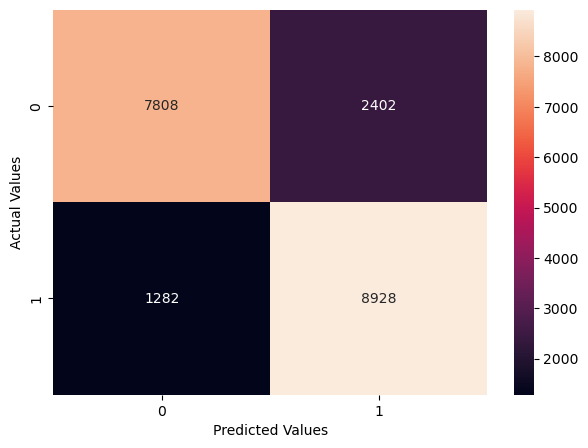

In [189]:
# Confusion matrix for oversampled train data
cm = confusion_matrix(y_train_over, pred_train)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

Text(58.222222222222214, 0.5, 'Actual Values')

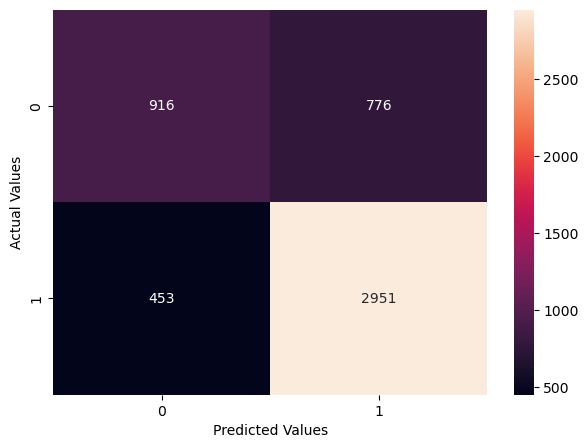

In [191]:
# Confusion matrix for oversampled validation data
cm = confusion_matrix(y_val, pred_val)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

Text(58.222222222222214, 0.5, 'Actual Values')

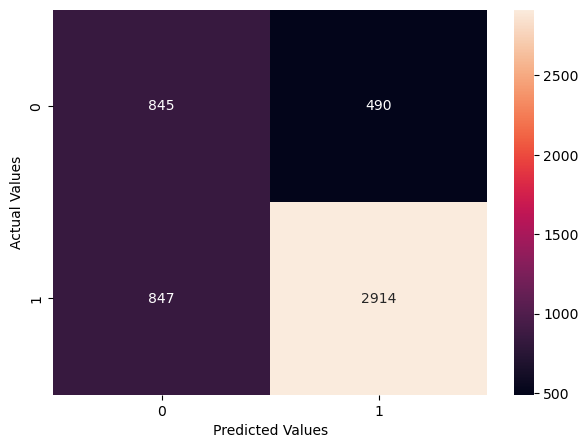

In [193]:
# Confusion matrix for oversampled test data
cm = confusion_matrix(pred_test, y_test)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

# **Important features of the final model**

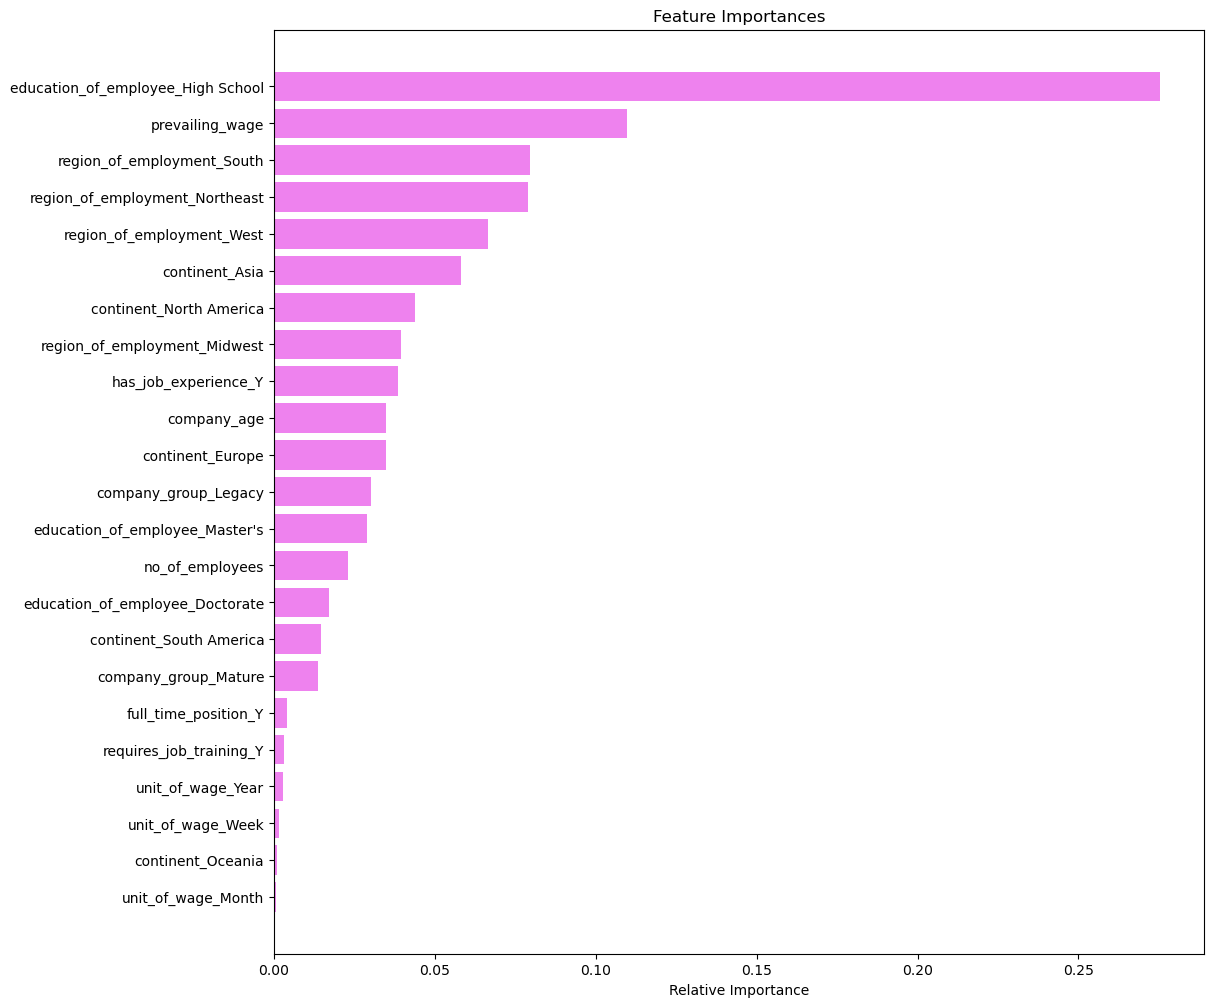

In [195]:
feature_names = X_train.columns
importances = gbm_best.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(
    range(len(indices)), importances[indices], color="violet", align="center"
)  # bar chart
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# **Actionable Insights and Recommendations**


* `education_of_employee_High School` is by far the most important feature, dominating the chart. This suggests that having only a high school education has a significant negative impact on the visa approval. Higher education like Masters and Doctorate has better advantage over others.

* `prevailing_wage` is the second most influential factor, as offered salary often needs to meet certain standards to demonstrate the job's legitimacy and prevent undercutting the local labor market. Hence the higher the wage, the higher the chances of certified approval as shown the plot where the median wage of the certified workers is higher than denied workers.

* Geography plays a big role, as the key considerations in the model are where the job is located and where the applicant comes from.

* Those with job experience have better chance of getting employed and certified for approval than those without.

* Other factors like Age of the company, company size, requiring job training also play vita roles in visa approval decisions.


### **Recommendations**

For Employers Sponsoring Visas:
- Ensure wage offers are robust and clearly meet prevailing wage requirements.
Understand that the job location might impact the perceived likelihood of visa approval.
- While focusing on qualifications, be mindful that factors like the applicant's highest education level might heavily influence the success prediction of models like this one.


___